In [ ]:
# Импорт библиотек

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import STL10, OxfordIIITPet

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import json
import csv
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Фиксация seed
def set_seed(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [ ]:
# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Папка с артефактами
os.makedirs('artifacts/figures', exist_ok=True)
print("Directories created successfully!")

Using device: cpu
Directories created successfully!


In [ ]:
# Определение transforms
base_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

aug_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

resnet_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загружаем STL10
print("Loading STL10 dataset...")
train_dataset_full = STL10(root='./data', split='train', download=True, transform=base_transform)
test_dataset = STL10(root='./data', split='test', download=True, transform=base_transform)

# Разделяем train на train и val (80/20)
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])

# Создаем версии с аугментациями и ResNet preprocessing
# Для аугментаций нужно использовать PIL изображения, поэтому создаем отдельный датасет без transform
train_dataset_raw = STL10(root='./data', split='train', download=True, transform=None)
train_dataset_resnet = STL10(root='./data', split='train', download=True, transform=None)
val_dataset_resnet = STL10(root='./data', split='train', download=True, transform=None)
test_dataset_resnet = STL10(root='./data', split='test', download=True, transform=None)

# Применяем transforms к сырым данным
class TransformDataset:
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

Loading STL10 dataset...


100%|██████████| 2.64G/2.64G [02:07<00:00, 20.7MB/s]


Train samples: 4000, Val: 1000, Test: 8000


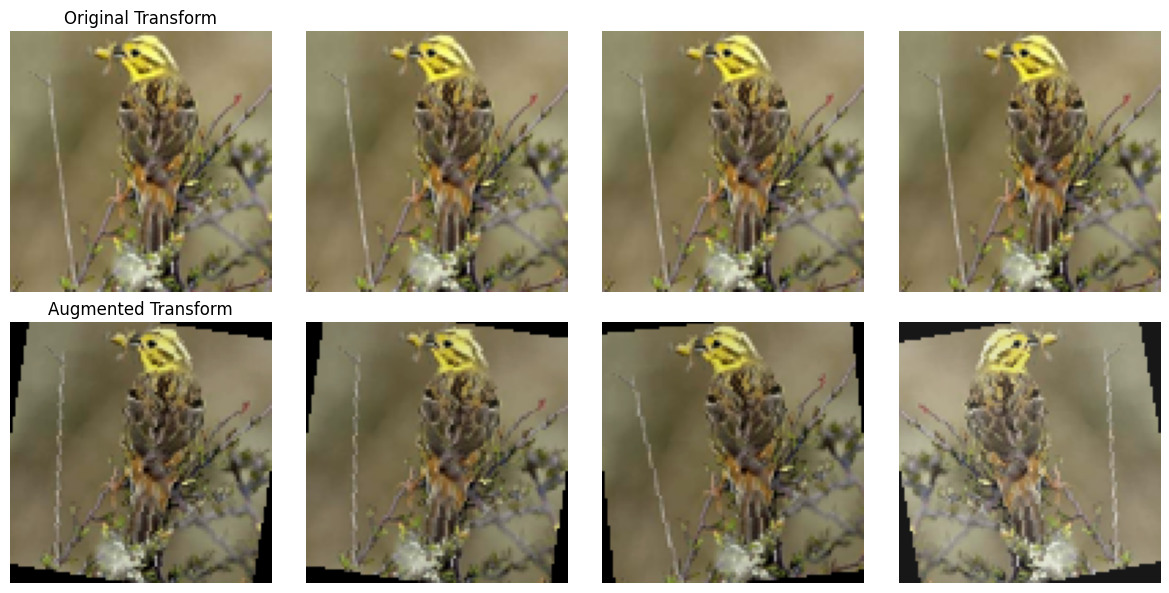

Augmentations preview saved!


In [ ]:
# Создание датасетов
train_dataset_aug = TransformDataset(train_dataset_raw, aug_transform)
train_dataset_resnet = TransformDataset(train_dataset_raw, resnet_transform)
val_dataset_resnet = TransformDataset(val_dataset_resnet, resnet_transform)
test_dataset_resnet = TransformDataset(test_dataset_resnet, resnet_transform)

# Разделение train для ResNet
train_dataset_resnet, _ = random_split(train_dataset_resnet, [train_size, val_size])
val_dataset_resnet, _ = random_split(val_dataset_resnet, [train_size, val_size])

# DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2)
train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# Визуализация аугментаций
def visualize_augmentations():
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))

    # Сырое изображение из датасета
    sample_img, _ = train_dataset_raw[0]

    for i, transform in enumerate([base_transform, aug_transform]):
        for j in range(4):
            if transform:
                img_tensor = transform(sample_img)
            else:
                img_tensor = sample_img

            # Конвертируем для отображения
            if isinstance(img_tensor, torch.Tensor):
                img = img_tensor.permute(1, 2, 0).numpy()
                if i == 0:
                    img = (img * 0.5 + 0.5).clip(0, 1)
                else:
                    img = (img * 0.5 + 0.5).clip(0, 1)
            else:
                img = np.array(img_tensor) / 255.0

            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(['Original Transform', 'Augmented Transform'][i])

    plt.tight_layout()
    plt.savefig('artifacts/figures/augmentations_preview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Augmentations preview saved!")

visualize_augmentations()

In [ ]:
# Определение модели SNN

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(256, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

In [ ]:
# Функция обучения на 1 эпохе
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), 100. * correct / total

In [ ]:
# Функция оценки
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), 100. * correct / total

In [ ]:
# Основной цикл обучения
def train_model(model, train_loader, val_loader, epochs, lr, device):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_model_state = 0, None

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()

    return history, best_model_state, best_val_acc

print("Model and training functions defined!")

Model and training functions defined!


In [ ]:
# 5 эпох
epochs = 5
lr = 0.001
results_c = {}
best_models = {}

# C1: Simple CNN без аугментаций
print("\n" + "="*50)
print("C1: Simple CNN без аугментаций (5 эпох)")
print("="*50)
model = SimpleCNN()
history, state, val_acc = train_model(model, train_loader, val_loader, epochs, lr, device)
results_c['C1'] = {'val_acc': val_acc, 'history': history}
best_models['C1'] = state

# C2: Simple CNN с аугментациями
print("\n" + "="*50)
print("C2: Simple CNN с аугментациями (5 эпох)")
print("="*50)
model = SimpleCNN()
history, state, val_acc = train_model(model, train_loader_aug, val_loader, epochs, lr, device)
results_c['C2'] = {'val_acc': val_acc, 'history': history}
best_models['C2'] = state

# C3: ResNet18 head-only
print("\n" + "="*50)
print("C3: ResNet18 head-only (5 эпох)")
print("="*50)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(512, 10)
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True
history, state, val_acc = train_model(model, train_loader_resnet, val_loader_resnet, epochs, lr, device)
results_c['C3'] = {'val_acc': val_acc, 'history': history}
best_models['C3'] = state

# C4: ResNet18 partial fine-tune
print("\n" + "="*50)
print("C4: ResNet18 partial fine-tune (5 эпох)")
print("="*50)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(512, 10)
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True
history, state, val_acc = train_model(model, train_loader_resnet, val_loader_resnet, epochs, lr, device)
results_c['C4'] = {'val_acc': val_acc, 'history': history}
best_models['C4'] = state

# Вывод результатов
print("\n" + "="*50)
print("CLASSIFICATION RESULTS (5 epochs):")
print("="*50)
for exp in ['C1', 'C2', 'C3', 'C4']:
    print(f"{exp}: Validation Accuracy = {results_c[exp]['val_acc']:.2f}%")


C1: Simple CNN без аугментаций (5 эпох)

Epoch 1/5


Evaluating: 100%|██████████| 16/16 [00:04<00:00,  3.88it/s]


Train Loss: 2.1353, Train Acc: 18.60%
Val Loss: 1.9519, Val Acc: 25.00%

Epoch 2/5


Evaluating: 100%|██████████| 16/16 [00:04<00:00,  3.40it/s]


Train Loss: 1.8420, Train Acc: 28.60%
Val Loss: 1.7269, Val Acc: 28.90%

Epoch 3/5


...

Train Loss: 0.0701, Train Acc: 97.75%
Val Loss: 0.1593, Val Acc: 95.88%

Epoch 4/5


Evaluating: 100%|██████████| 63/63 [00:21<00:00,  2.92it/s]


Train Loss: 0.0780, Train Acc: 97.15%
Val Loss: 0.1572, Val Acc: 95.85%

Epoch 5/5


Evaluating: 100%|██████████| 63/63 [00:21<00:00,  3.00it/s]

Train Loss: 0.0632, Train Acc: 97.92%
Val Loss: 0.1538, Val Acc: 96.08%

CLASSIFICATION RESULTS (5 epochs):
C1: Validation Accuracy = 38.20%
C2: Validation Accuracy = 39.90%
C3: Validation Accuracy = 83.03%
C4: Validation Accuracy = 96.08%


In [ ]:
# Выбор лучшей модели
best_exp = max(results_c, key=lambda x: results_c[x]['val_acc'])
best_model_state = best_models[best_exp]
print(f"\n Лучший эксперимент: {best_exp} с val_accuracy = {results_c[best_exp]['val_acc']:.2f}%")

torch.save(best_model_state, 'artifacts/best_classifier.pt')

config = {
    'dataset': 'STL10', 'experiment_id': best_exp,
    'architecture': 'ResNet18' if best_exp in ['C3', 'C4'] else 'SimpleCNN',
    'num_classes': 10, 'seed': 42, 'epochs': epochs,
    'best_val_accuracy': results_c[best_exp]['val_acc']
}
with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=2)


 Лучший эксперимент: C4 с val_accuracy = 96.08%


In [ ]:
# Тестирование лучшей модели
if best_exp in ['C3', 'C4']:
    final_model = models.resnet18(weights=None)
    final_model.fc = nn.Linear(512, 10)
    test_loader_final = test_loader_resnet
else:
    final_model = SimpleCNN()
    test_loader_final = test_loader

final_model.load_state_dict(best_model_state)
final_model = final_model.to(device)
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(final_model, test_loader_final, criterion, device)

print(f"\nTest Accuracy: {test_acc:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Evaluating: 100%|██████████| 125/125 [00:41<00:00,  3.00it/s]


Test Accuracy: 83.75%
Test Loss: 0.6440


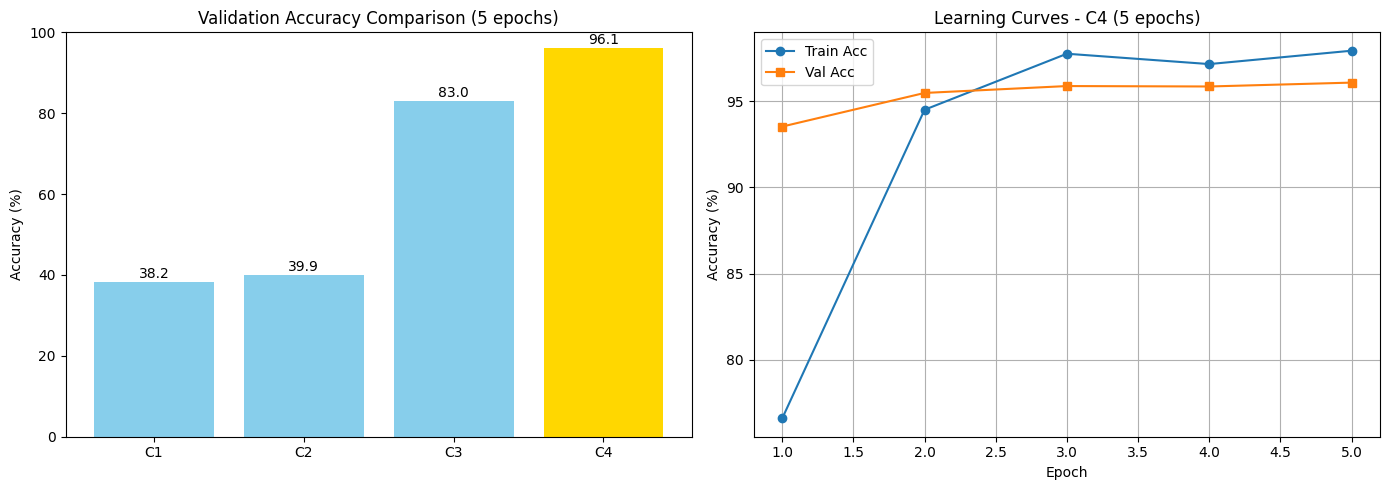

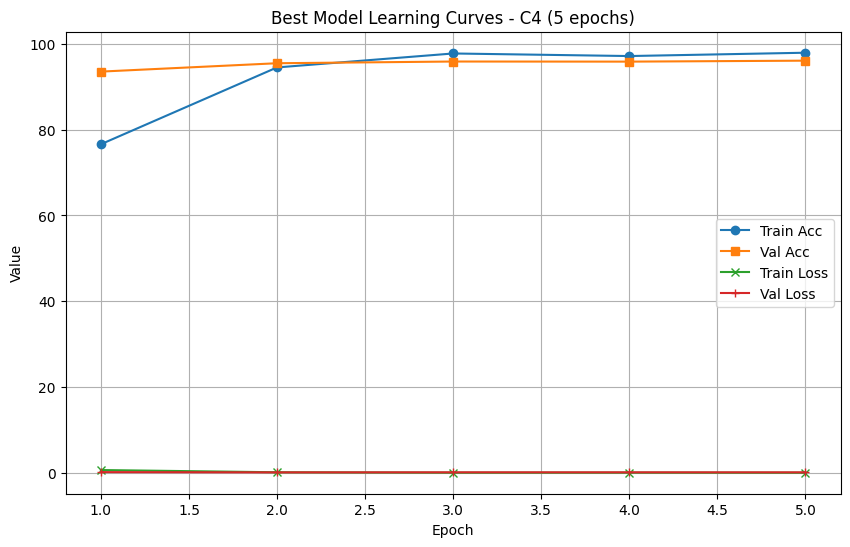

In [ ]:
# Графики сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

experiments = list(results_c.keys())
val_accs = [results_c[e]['val_acc'] for e in experiments]
colors = ['gold' if e == best_exp else 'skyblue' for e in experiments]
axes[0].bar(experiments, val_accs, color=colors)
axes[0].set_title(f'Validation Accuracy Comparison ({epochs} epochs)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(val_accs):
    axes[0].text(i, v + 1, f'{v:.1f}', ha='center')

best_history = results_c[best_exp]['history']
epochs_range = range(1, len(best_history['train_acc']) + 1)
axes[1].plot(epochs_range, best_history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(epochs_range, best_history['val_acc'], label='Val Acc', marker='s')
axes[1].set_title(f'Learning Curves - {best_exp} ({epochs} epochs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/classification_compare.png', dpi=150, bbox_inches='tight')
plt.show()

# График кривых
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, best_history['train_acc'], label='Train Acc', marker='o')
plt.plot(epochs_range, best_history['val_acc'], label='Val Acc', marker='s')
plt.plot(epochs_range, best_history['train_loss'], label='Train Loss', marker='x')
plt.plot(epochs_range, best_history['val_loss'], label='Val Loss', marker='+')
plt.title(f'Best Model Learning Curves - {best_exp} ({epochs} epochs)')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/classification_curves_best.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Функции для сегментации
def segmentation_transform(image, target):
    image_tensor = transforms.ToTensor()(image)
    mask_tensor = transforms.ToTensor()(target)
    mask_tensor = (mask_tensor * 255).long().squeeze(0)
    return image_tensor, mask_tensor

def compute_iou(pred_mask, true_mask):
    pred_mask, true_mask = pred_mask.float(), true_mask.float()
    intersection = (pred_mask * true_mask).sum()
    union = pred_mask.sum() + true_mask.sum() - intersection
    return intersection / union if union > 0 else torch.tensor(0.0)

def visualize_segmentation(image, true_mask, pred_mask, idx, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    img = image.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    axes[0].imshow(img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    true_binary = (true_mask > 0).float()
    axes[1].imshow(img)
    axes[1].imshow(true_binary.cpu().numpy(), alpha=0.5, cmap='Reds')
    axes[1].set_title('Ground Truth Mask')
    axes[1].axis('off')

    axes[2].imshow(img)
    axes[2].imshow(pred_mask.cpu().numpy(), alpha=0.5, cmap='Greens')
    axes[2].set_title('Predicted Mask')
    axes[2].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def morphological_cleaning(mask, kernel_size=5):
    from scipy import ndimage
    mask_np = mask.cpu().numpy()
    structure = np.ones((kernel_size, kernel_size))
    cleaned = ndimage.binary_opening(mask_np, structure=structure)
    return torch.from_numpy(cleaned)

# Загрузка OxfordIIITPet
print("Loading OxfordIIITPet dataset...")
pet_dataset = OxfordIIITPet(
    root='./data', split='trainval', target_types='segmentation',
    download=True, transform=segmentation_transform
)

# Выбор 30 изображений (для наиболее скорого выполнения)
subset_indices = list(range(30))
pet_dataset = Subset(pet_dataset, subset_indices)
print(f"Dataset size: {len(pet_dataset)}")

# Загрузка модели сегментации
print("Loading DeepLabV3 model...")
seg_model = torchvision.models.segmentation.deeplabv3_resnet50(weights='DEFAULT')
seg_model = seg_model.to(device)
seg_model.eval()
print("Model loaded!")

Loading OxfordIIITPet dataset...


100%|██████████| 792M/792M [00:34<00:00, 22.9MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.0MB/s]


Dataset size: 30
Loading DeepLabV3 model...
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:07<00:00, 22.4MB/s]


Model loaded!


In [ ]:
# Функции для сегментации
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms as T

# Определение transforms для изображения и маски отдельно
image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

mask_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

def compute_iou(pred_mask, true_mask):
    """Compute IoU for binary masks"""
    pred_mask = pred_mask.float()
    true_mask = true_mask.float()

    intersection = (pred_mask * true_mask).sum()
    union = pred_mask.sum() + true_mask.sum() - intersection

    if union == 0:
        return torch.tensor(0.0)
    return intersection / union

def visualize_segmentation(image, true_mask, pred_mask, idx, save_path=None):
    """Visualize segmentation results"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Денормализация изображения
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = image * std + mean
    img = img.permute(1, 2, 0).cpu().numpy()
    img = img.clip(0, 1)

    axes[0].imshow(img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    true_binary = (true_mask > 0).float()
    axes[1].imshow(img)
    axes[1].imshow(true_binary.cpu().numpy(), alpha=0.5, cmap='Reds')
    axes[1].set_title('Ground Truth Mask')
    axes[1].axis('off')

    axes[2].imshow(img)
    axes[2].imshow(pred_mask.cpu().numpy(), alpha=0.5, cmap='Greens')
    axes[2].set_title('Predicted Mask')
    axes[2].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

def morphological_cleaning(mask, kernel_size=5):
    """Apply morphological opening to remove small components"""
    from scipy import ndimage
    mask_np = mask.cpu().numpy()
    structure = np.ones((kernel_size, kernel_size))
    cleaned = ndimage.binary_opening(mask_np, structure=structure)
    return torch.from_numpy(cleaned)

# Загрузка OxfordIIITPet с правильными transforms
print("Loading OxfordIIITPet dataset...")

class PetDataset:
    """Wrapper for OxfordIIITPet with proper transforms"""
    def __init__(self, root='./data', split='trainval', image_transform=None, mask_transform=None):
        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types='segmentation',
            download=True
        )
        self.image_transform = image_transform
        self.mask_transform = mask_transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, target = self.dataset[idx]  # target is a PIL Image with segmentation mask

        if self.image_transform:
            image = self.image_transform(image)

        if self.mask_transform:
            target = self.mask_transform(target)
            target = (target * 255).long().squeeze(0)  # Convert to class indices

        return image, target

Loading OxfordIIITPet dataset...


In [ ]:
# Датасет
pet_dataset_full = PetDataset(
    root='./data',
    split='trainval',
    image_transform=image_transform,
    mask_transform=mask_transform
)

subset_indices = list(range(30))
pet_dataset = Subset(pet_dataset_full, subset_indices)
print(f"Dataset size: {len(pet_dataset)}")

# Проверка на примере
sample_img, sample_mask = pet_dataset[0]
print(f"Image shape: {sample_img.shape}")
print(f"Mask shape: {sample_mask.shape}")
print(f"Mask unique values: {torch.unique(sample_mask)}")

# Загрузка модели сегментации
print("\nLoading DeepLabV3 model...")
seg_model = torchvision.models.segmentation.deeplabv3_resnet50(weights='DEFAULT')
seg_model = seg_model.to(device)
seg_model.eval()
print("Model loaded!")

# Тестирование модели на примере
with torch.no_grad():
    test_input = sample_img.unsqueeze(0).to(device)
    test_output = seg_model(test_input)['out']
    print(f"Output shape: {test_output.shape}")

Dataset size: 30
Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([256, 256])
Mask unique values: tensor([1, 2, 3])

Loading DeepLabV3 model...
Model loaded!
Output shape: torch.Size([1, 21, 256, 256])


In [ ]:
# V1: Базовая постобработка (argmax)
print("\n" + "="*50)
print("V1: Базовая постобработка (argmax)")
print("="*50)

ious_v1 = []
images_v1 = []
true_masks_v1 = []
pred_masks_v1 = []

with torch.no_grad():
    for idx, (image, mask) in enumerate(tqdm(pet_dataset, desc='V1')):
        image = image.unsqueeze(0).to(device)

        # Inference
        output = seg_model(image)['out']
        pred = torch.softmax(output, dim=1)

        # Get predicted class (argmax)
        pred_class = pred.argmax(dim=1).squeeze(0).cpu()

        # Convert to binary mask for foreground (class > 0)
        pred_binary = (pred_class > 0).float()

        # Ground truth binary mask
        true_binary = (mask > 0).float()

        # Compute IoU
        iou = compute_iou(pred_binary, true_binary)
        ious_v1.append(iou.item())

        # Store for visualization
        if idx < 3:
            images_v1.append(image.squeeze(0).cpu())
            true_masks_v1.append(true_binary)
            pred_masks_v1.append(pred_binary)

mean_iou_v1 = np.mean(ious_v1) if ious_v1 else 0
std_iou_v1 = np.std(ious_v1) if ious_v1 else 0
print(f"\nMean IoU (V1): {mean_iou_v1:.4f} ± {std_iou_v1:.4f}")

# Visualize V1 results
for i in range(len(images_v1)):
    visualize_segmentation(
        images_v1[i], true_masks_v1[i], pred_masks_v1[i], i,
        f'artifacts/figures/segmentation_v1_{i}.png'
    )

# V2: Морфологическая очистка
print("\n" + "="*50)
print("V2: Морфологическая очистка")
print("="*50)

ious_v2 = []
images_v2 = []
true_masks_v2 = []
pred_masks_v2 = []

with torch.no_grad():
    for idx, (image, mask) in enumerate(tqdm(pet_dataset, desc='V2')):
        image = image.unsqueeze(0).to(device)

        # Inference
        output = seg_model(image)['out']
        pred = torch.softmax(output, dim=1)

        # Get predicted class
        pred_class = pred.argmax(dim=1).squeeze(0).cpu()

        # Convert to binary mask
        pred_binary = (pred_class > 0).float()

        # Apply morphological cleaning
        pred_binary = morphological_cleaning(pred_binary, kernel_size=5)

        # Ground truth binary mask
        true_binary = (mask > 0).float()

        # Compute IoU
        iou = compute_iou(pred_binary, true_binary)
        ious_v2.append(iou.item())

        # Store for visualization
        if idx < 3:
            images_v2.append(image.squeeze(0).cpu())
            true_masks_v2.append(true_binary)
            pred_masks_v2.append(pred_binary)

mean_iou_v2 = np.mean(ious_v2) if ious_v2 else 0
std_iou_v2 = np.std(ious_v2) if ious_v2 else 0
print(f"\nMean IoU (V2): {mean_iou_v2:.4f} ± {std_iou_v2:.4f}")

# Visualize V2 results
for i in range(len(images_v2)):
    visualize_segmentation(
        images_v2[i], true_masks_v2[i], pred_masks_v2[i], i,
        f'artifacts/figures/segmentation_v2_{i}.png'
    )


V1: Базовая постобработка (argmax)


V1: 100%|██████████| 30/30 [00:14<00:00,  2.06it/s]



Mean IoU (V1): 0.4318 ± 0.2203

V2: Морфологическая очистка


V2: 100%|██████████| 30/30 [00:19<00:00,  1.53it/s]



Mean IoU (V2): 0.4313 ± 0.2204


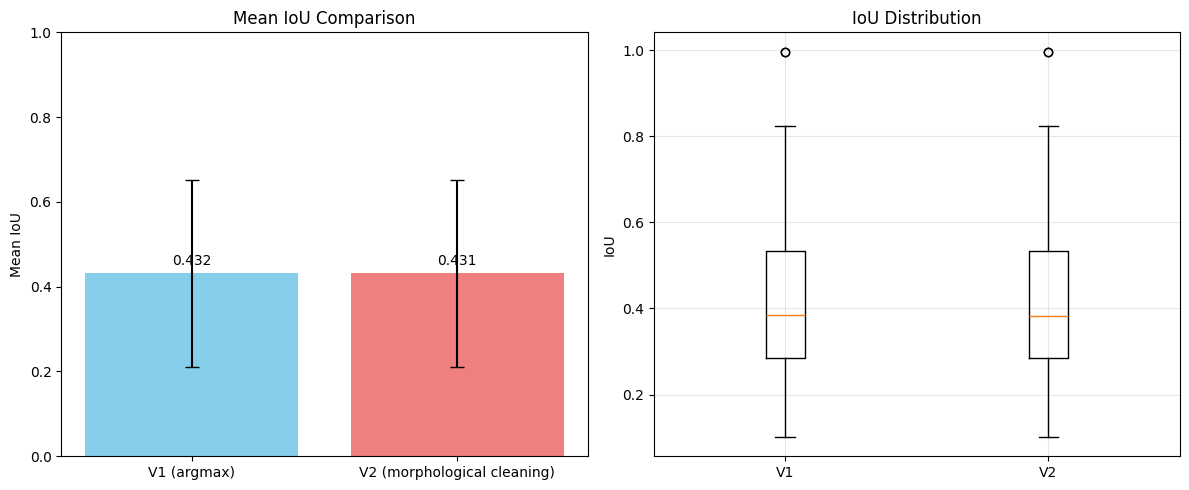


----------------------------------------
SEGMENTATION RESULTS:
----------------------------------------
V1 (argmax): Mean IoU = 0.4318 ± 0.2203
V2 (morphological cleaning): Mean IoU = 0.4313 ± 0.2204


In [ ]:
# Сравнительный график
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

versions = ['V1 (argmax)', 'V2 (morphological cleaning)']
ious = [mean_iou_v1, mean_iou_v2]
std_ious = [std_iou_v1, std_iou_v2]

axes[0].bar(versions, ious, yerr=std_ious, color=['skyblue', 'lightcoral'], capsize=5)
axes[0].set_title('Mean IoU Comparison')
axes[0].set_ylabel('Mean IoU')
axes[0].set_ylim(0, 1)
for i, v in enumerate(ious):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center')

axes[1].boxplot([ious_v1, ious_v2], labels=['V1', 'V2'])
axes[1].set_title('IoU Distribution')
axes[1].set_ylabel('IoU')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "-"*40)
print("SEGMENTATION RESULTS:")
print("-"*40)
print(f"V1 (argmax): Mean IoU = {mean_iou_v1:.4f} ± {std_iou_v1:.4f}")
print(f"V2 (morphological cleaning): Mean IoU = {mean_iou_v2:.4f} ± {std_iou_v2:.4f}")

In [ ]:
# Сохранение результатов в CSV
csv_data = [
    {'experiment_id': 'C1', 'task': 'classification', 'dataset': 'STL10', 'seed': 42,
     'model_summary': 'SimpleCNN', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': epochs,
     'best_val_accuracy': results_c['C1']['val_acc'], 'test_accuracy': test_acc if best_exp == 'C1' else None,
     'mean_iou': None, 'notes': 'Simple CNN without augmentations (5 epochs)'},

    {'experiment_id': 'C2', 'task': 'classification', 'dataset': 'STL10', 'seed': 42,
     'model_summary': 'SimpleCNN', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': epochs,
     'best_val_accuracy': results_c['C2']['val_acc'], 'test_accuracy': test_acc if best_exp == 'C2' else None,
     'mean_iou': None, 'notes': 'Simple CNN with augmentations (5 epochs)'},

    {'experiment_id': 'C3', 'task': 'classification', 'dataset': 'STL10', 'seed': 42,
     'model_summary': 'ResNet18', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': epochs,
     'best_val_accuracy': results_c['C3']['val_acc'], 'test_accuracy': test_acc if best_exp == 'C3' else None,
     'mean_iou': None, 'notes': 'ResNet18 head-only (5 epochs)'},

    {'experiment_id': 'C4', 'task': 'classification', 'dataset': 'STL10', 'seed': 42,
     'model_summary': 'ResNet18', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': epochs,
     'best_val_accuracy': results_c['C4']['val_acc'], 'test_accuracy': test_acc if best_exp == 'C4' else None,
     'mean_iou': None, 'notes': 'ResNet18 partial fine-tune (5 epochs)'},

    {'experiment_id': 'V1', 'task': 'segmentation', 'dataset': 'OxfordIIITPet', 'seed': 42,
     'model_summary': 'DeepLabV3_ResNet50', 'optimizer': None, 'lr': None, 'epochs_trained': 0,
     'best_val_accuracy': None, 'test_accuracy': None, 'mean_iou': mean_iou_v1,
     'notes': 'Threshold=0.5, argmax prediction (30 images)'},

    {'experiment_id': 'V2', 'task': 'segmentation', 'dataset': 'OxfordIIITPet', 'seed': 42,
     'model_summary': 'DeepLabV3_ResNet50', 'optimizer': None, 'lr': None, 'epochs_trained': 0,
     'best_val_accuracy': None, 'test_accuracy': None, 'mean_iou': mean_iou_v2,
     'notes': 'Morphological cleaning (opening with 5x5 kernel, 30 images)'},
]

fieldnames = ['experiment_id', 'task', 'dataset', 'seed', 'model_summary', 'optimizer',
              'lr', 'epochs_trained', 'best_val_accuracy', 'test_accuracy', 'mean_iou', 'notes']

with open('artifacts/runs.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(csv_data)

print("Results saved to artifacts/runs.csv")

Results saved to artifacts/runs.csv


In [ ]:
# Вывод результатов
print("\n" + "="*50)
print("FINAL SUMMARY - HW10-11")
print("="*50)

print("\n" + "-"*40)
print(f"CLASSIFICATION RESULTS ({epochs} epochs)")
print("-"*40)
for exp in ['C1', 'C2', 'C3', 'C4']:
    print(f"{exp}: Validation Accuracy = {results_c[exp]['val_acc']:.2f}%")

print(f"\n BEST classification experiment: {best_exp}")
print(f"   Best validation accuracy: {results_c[best_exp]['val_acc']:.2f}%")
print(f"   Test accuracy: {test_acc:.2f}%")

print("\n" + "-"*40)
print("SEGMENTATION RESULTS (30 images)")
print("-"*40)
print(f"V1 (threshold=0.5): Mean IoU = {mean_iou_v1:.4f} ± {std_iou_v1:.4f}")
print(f"V2 (morphological cleaning): Mean IoU = {mean_iou_v2:.4f} ± {std_iou_v2:.4f}")

print("\n" + "-"*40)
print("SAVED FILES:")
print("-"*40)
print("✓ artifacts/best_classifier.pt")
print("✓ artifacts/best_classifier_config.json")
print("✓ artifacts/runs.csv")
print("✓ artifacts/figures/augmentations_preview.png")
print("✓ artifacts/figures/classification_compare.png")
print("✓ artifacts/figures/classification_curves_best.png")
print("✓ artifacts/figures/segmentation_metrics.png")
print("✓ artifacts/figures/segmentation_v1_*.png")
print("✓ artifacts/figures/segmentation_v2_*.png")


FINAL SUMMARY - HW10-11

----------------------------------------
CLASSIFICATION RESULTS (5 epochs)
----------------------------------------
C1: Validation Accuracy = 38.20%
C2: Validation Accuracy = 39.90%
C3: Validation Accuracy = 83.03%
C4: Validation Accuracy = 96.08%

 BEST classification experiment: C4
   Best validation accuracy: 96.08%
   Test accuracy: 83.75%

----------------------------------------
SEGMENTATION RESULTS (30 images)
----------------------------------------
V1 (threshold=0.5): Mean IoU = 0.4318 ± 0.2203
V2 (morphological cleaning): Mean IoU = 0.4313 ± 0.2204

----------------------------------------
SAVED FILES:
----------------------------------------
✓ artifacts/best_classifier.pt
✓ artifacts/best_classifier_config.json
✓ artifacts/runs.csv
✓ artifacts/figures/augmentations_preview.png
✓ artifacts/figures/classification_compare.png
✓ artifacts/figures/classification_curves_best.png
✓ artifacts/figures/segmentation_metrics.png
✓ artifacts/figures/segmentation